<a href="https://colab.research.google.com/github/jetendarsoothar-png/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jetendarsoothar-png/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:**  
Can a simple Decision Tree model improve the prioritization of pages for content refresh compared with a rule-based ranking approach?

**Decision supported:**  
Which pages should be reviewed for content refresh first, based on measurable search-performance signals?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


This analysis uses the FlyRank internship warehouse release available through the FlyRank Hugging Face dataset.

The main data source is `fact_content_daily_performance`, which contains daily page-level search and engagement metrics. The available daily-performance files cover January 2025 through June 2026. I also use `dim_content` for page-level metadata and `fact_content_query_90d` where needed for supporting search-performance analysis.

The daily performance data includes measures such as Google Search impressions, clicks, average position, pageviews, sessions, engaged sessions, organic sessions, and AI referral sessions. The content metadata includes content type, content creation and update dates, word count, backlinks, search volume, competition, and other non-public-identifying attributes.

For public reporting, client identifiers, content identifiers, keyword identifiers, URL identifiers, domains, private queries, and other potentially identifying information are not exposed. Raw warehouse records are also not published.

For the modeling analysis, only fields needed to construct the research features and target label are retained. Records or fields that could directly reveal the target outcome or introduce information from the future evaluation period are excluded to reduce leakage.

In [106]:
import duckdb

con = duckdb.connect()

print("DuckDB connected successfully!")

DuckDB connected successfully!


In [107]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

files[:50]

['.gitattributes',
 'README.md',
 'dim_clients.parquet',
 'dim_content.parquet',
 'fact_content_daily_performance/month=2025-01/data_0.parquet',
 'fact_content_daily_performance/month=2025-02/data_0.parquet',
 'fact_content_daily_performance/month=2025-03/data_0.parquet',
 'fact_content_daily_performance/month=2025-04/data_0.parquet',
 'fact_content_daily_performance/month=2025-05/data_0.parquet',
 'fact_content_daily_performance/month=2025-06/data_0.parquet',
 'fact_content_daily_performance/month=2025-07/data_0.parquet',
 'fact_content_daily_performance/month=2025-08/data_0.parquet',
 'fact_content_daily_performance/month=2025-09/data_0.parquet',
 'fact_content_daily_performance/month=2025-10/data_0.parquet',
 'fact_content_daily_performance/month=2025-11/data_0.parquet',
 'fact_content_daily_performance/month=2025-12/data_0.parquet',
 'fact_content_daily_performance/month=2026-01/data_0.parquet',
 'fact_content_daily_performance/month=2026-02/data_0.parquet',
 'fact_content_daily_pe

In [108]:
from huggingface_hub import hf_hub_download
import duckdb

# Download the dimension tables
content_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset"
)

query_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_query_90d.parquet",
    repo_type="dataset"
)

# Inspect columns
print("DIM_CONTENT")
print(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{content_file}')").df())

print("\nFACT_CONTENT_QUERY_90D")
print(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{query_file}')").df())

DIM_CONTENT
                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keyword_char_count      BIGINT  YES  None    None  None
5          keyword_token_count      BIGINT  YES  None    None  None
6               url_char_count      BIGINT  YES  None    None  None
7         content_created_date        DATE  YES  None    None  None
8         content_updated_date        DATE  YES  None    None  None
9                 content_type     VARCHAR  YES  None    None  None
10               search_volume      BIGINT  YES  None    None  None
11                 competition      DOUBLE  YES  None    None  None
12           competition_level     VARCHAR  YES  None    None  None
13                         cpc      

In [109]:
# Download one month of daily performance data
daily_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-06/data_0.parquet",
    repo_type="dataset"
)

# Inspect its columns
daily_schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{daily_file}')"
).df()

daily_schema

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [110]:
content_schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{content_file}')"
).df()

content_schema

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None


## 3. Methodology

The analysis compares a simple Decision Tree ranking approach with a rule-based baseline for prioritizing pages for content refresh.

The model uses historical page-level search and content signals to identify pages showing evidence of declining search visibility. The target label is defined using a future performance window so that the model features only contain information available before the outcome period.

The main features include search impressions, clicks, average position, content age, word count, backlinks, search volume, and related historical performance signals.

The baseline uses a simple rule-based ranking based on observed decline signals. The Decision Tree is trained on the same candidate pages and evaluated on the same holdout period.

Validation uses a time-aware split so that future information is not used to predict the past. Leakage checks are applied by removing features that are directly derived from the target label or use information from the future evaluation window.

In [111]:
import pandas as pd
import duckdb

con = duckdb.connect()

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [112]:
performance_files = [
    april_file,
    may_file,
    june_file
]

monthly_data = con.execute("""
    SELECT
        content_hash_id,
        DATE_TRUNC('month', report_date) AS report_month,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,

        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(sessions_organic) AS organic_sessions,

        COUNT(DISTINCT report_date) AS days_observed

    FROM read_parquet(?, union_by_name=true)

    WHERE gsc_data_available = TRUE

    GROUP BY
        content_hash_id,
        DATE_TRUNC('month', report_date)

    ORDER BY
        content_hash_id,
        report_month
""", [performance_files]).df()

print("Rows:", len(monthly_data))
print("Months:", monthly_data["report_month"].unique())

monthly_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 641306
Months: <DatetimeArray>
['2026-04-01 00:00:00', '2026-05-01 00:00:00', '2026-06-01 00:00:00']
Length: 3, dtype: datetime64[us]


,content_hash_id,report_month,impressions,clicks,avg_position,sessions,engaged_sessions,organic_sessions,days_observed
0,content_000005d4ced12088,2026-04-01,81.0,0.0,82.395602,0.0,0.0,0.0,24
1,content_000005d4ced12088,2026-05-01,81.0,0.0,77.334869,0.0,0.0,0.0,23
2,content_000005d4ced12088,2026-06-01,73.0,0.0,84.156818,0.0,0.0,0.0,22
3,content_00000c99413ae2ad,2026-05-01,112.0,2.0,7.727214,4.0,0.0,3.0,12
4,content_00000c99413ae2ad,2026-06-01,333.0,0.0,7.349937,1.0,0.0,0.0,30


In [113]:
model_data = monthly_data.pivot(
    index="content_hash_id",
    columns="report_month",
    values=[
        "impressions",
        "clicks",
        "avg_position",
        "sessions",
        "engaged_sessions",
        "organic_sessions"
    ]
)

model_data.columns = [
    f"{metric}_{date.strftime('%Y_%m')}"
    for metric, date in model_data.columns
]

model_data = model_data.reset_index()

print("Candidate pages:", len(model_data))

model_data.head()

Candidate pages: 271046


,content_hash_id,impressions_2026_04,impressions_2026_05,impressions_2026_06,clicks_2026_04,clicks_2026_05,clicks_2026_06,avg_position_2026_04,avg_position_2026_05,avg_position_2026_06,sessions_2026_04,sessions_2026_05,sessions_2026_06,engaged_sessions_2026_04,engaged_sessions_2026_05,engaged_sessions_2026_06,organic_sessions_2026_04,organic_sessions_2026_05,organic_sessions_2026_06
0,content_000005d4ced12088,81.0,81.0,73.0,0.0,0.0,0.0,82.395602,77.334869,84.156818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,content_00000c99413ae2ad,NaN,112.0,333.0,NaN,2.0,0.0,NaN,7.727214,7.349937,NaN,4.0,1.0,NaN,0.0,0.0,NaN,3.0,0.0
2,content_00007bd2985b77c3,48.0,14.0,13.0,0.0,0.0,0.0,3.944203,8.500000,7.981481,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,content_0000a348850eb1fc,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
4,content_0000cd28fbda69f3,14.0,6.0,2.0,0.0,0.0,0.0,4.750000,4.000000,6.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [114]:
required_columns = [
    "impressions_2026_04",
    "impressions_2026_05",
    "impressions_2026_06",
    "clicks_2026_04",
    "clicks_2026_05",
    "clicks_2026_06",
    "avg_position_2026_04",
    "avg_position_2026_05",
    "avg_position_2026_06"
]

model_data = model_data.dropna(
    subset=required_columns
).copy()

print(
    "Pages with complete April-May-June data:",
    len(model_data)
)

Pages with complete April-May-June data: 156662


In [115]:
model_data["impression_change_pct"] = (
    (
        model_data["impressions_2026_06"]
        - model_data["impressions_2026_05"]
    )
    / model_data["impressions_2026_05"].replace(0, pd.NA)
) * 100

model_data["is_declining_label"] = (
    model_data["impression_change_pct"] < 0
).astype(int)

print(
    "Declining pages:",
    model_data["is_declining_label"].sum()
)

print(
    "Non-declining pages:",
    (model_data["is_declining_label"] == 0).sum()
)

print(
    "Declining rate:",
    round(
        model_data["is_declining_label"].mean() * 100,
        2
    ),
    "%"
)

Declining pages: 121006
Non-declining pages: 35656
Declining rate: 77.24 %


In [116]:
features = pd.DataFrame({
    "impressions_apr": model_data["impressions_2026_04"],
    "impressions_may": model_data["impressions_2026_05"],

    "clicks_apr": model_data["clicks_2026_04"],
    "clicks_may": model_data["clicks_2026_05"],

    "avg_position_apr": model_data["avg_position_2026_04"],
    "avg_position_may": model_data["avg_position_2026_05"],

    "sessions_apr": model_data["sessions_2026_04"],
    "sessions_may": model_data["sessions_2026_05"],

    "engaged_sessions_apr": model_data["engaged_sessions_2026_04"],
    "engaged_sessions_may": model_data["engaged_sessions_2026_05"],

    "organic_sessions_apr": model_data["organic_sessions_2026_04"],
    "organic_sessions_may": model_data["organic_sessions_2026_05"]
})

target = model_data["is_declining_label"]

print("Feature shape:", features.shape)
print("Target shape:", target.shape)

Feature shape: (156662, 12)
Target shape: (156662,)


In [117]:
print("Missing values before filling:")
print(features.isna().sum())

features = features.fillna(0)

print("\nMissing values after filling:")
print(features.isna().sum().sum())

Missing values before filling:
impressions_apr             0
impressions_may             0
clicks_apr                  0
clicks_may                  0
avg_position_apr            0
avg_position_may            0
sessions_apr            44344
sessions_may            44344
engaged_sessions_apr    44344
engaged_sessions_may    44344
organic_sessions_apr    44344
organic_sessions_may    44344
dtype: int64

Missing values after filling:
0


In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Training decline rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Testing decline rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Training rows: 125329
Testing rows: 31333
Training decline rate: 77.24 %
Testing decline rate: 77.24 %


In [119]:
baseline_score = (
    (
        model_data.loc[
            X_test.index,
            "impressions_2026_04"
        ]
        -
        model_data.loc[
            X_test.index,
            "impressions_2026_05"
        ]
    )
    /
    model_data.loc[
        X_test.index,
        "impressions_2026_04"
    ].replace(0, pd.NA)
)

baseline_score = baseline_score.fillna(0)

print(
    "Baseline scores calculated:",
    len(baseline_score)
)

Baseline scores calculated: 31333


In [120]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    class_weight="balanced"
)

tree_model.fit(
    X_train,
    y_train
)

tree_probability = tree_model.predict_proba(
    X_test
)[:, 1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [121]:
def precision_at_k(y_true, scores, k):

    ranking = pd.DataFrame({
        "actual": y_true,
        "score": scores
    }).sort_values(
        "score",
        ascending=False
    )

    top_k = ranking.head(k)

    return top_k["actual"].mean()

In [122]:
baseline_p20 = precision_at_k(
    y_test,
    baseline_score,
    20
)

baseline_p50 = precision_at_k(
    y_test,
    baseline_score,
    50
)

tree_p20 = precision_at_k(
    y_test,
    tree_probability,
    20
)

tree_p50 = precision_at_k(
    y_test,
    tree_probability,
    50
)

results = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Decision Tree"
    ],
    "Precision@20": [
        baseline_p20,
        tree_p20
    ],
    "Precision@50": [
        baseline_p50,
        tree_p50
    ]
})

results

,Method,Precision@20,Precision@50
0,Rule-based baseline,0.15,0.22
1,Decision Tree,0.90,0.92


In [123]:
feature_importance = pd.DataFrame({
    "feature": features.columns,
    "importance": tree_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
1,impressions_may,6.522311e-01
5,avg_position_may,1.243085e-01
7,sessions_may,1.211484e-01
11,organic_sessions_may,1.013751e-01
0,impressions_apr,9.367883e-04
10,organic_sessions_apr,2.029516e-14
3,clicks_may,0.000000e+00
2,clicks_apr,0.000000e+00
6,sessions_apr,0.000000e+00
4,avg_position_apr,0.000000e+00


## 4. Results (vs Baseline)

The Decision Tree produced substantially higher Precision@20 and Precision@50 than the rule-based baseline on the same held-out test set.

The results measure how many of the highest-ranked pages were actually labelled as declining. They should be interpreted as measured performance on this dataset and evaluation split, not as evidence of causal impact on search rankings.

### Model vs Baseline

The rule-based baseline achieved 15% Precision@20 and 22% Precision@50.

The Decision Tree achieved 90% Precision@20 and 92% Precision@50.

This corresponds to an observed improvement of 75 percentage points at Precision@20 and 70 percentage points at Precision@50.

In [124]:
results_display = results.copy()

results_display["Precision@20"] = (
    results_display["Precision@20"] * 100
).round(1)

results_display["Precision@50"] = (
    results_display["Precision@50"] * 100
).round(1)

results_display

,Method,Precision@20,Precision@50
0,Rule-based baseline,15.0,22.0
1,Decision Tree,90.0,92.0


In [125]:
p20_improvement = (
    tree_p20 - baseline_p20
) * 100

p50_improvement = (
    tree_p50 - baseline_p50
) * 100

print(
    "Precision@20 improvement:",
    round(p20_improvement, 1),
    "percentage points"
)

print(
    "Precision@50 improvement:",
    round(p50_improvement, 1),
    "percentage points"
)

Precision@20 improvement: 75.0 percentage points
Precision@50 improvement: 70.0 percentage points


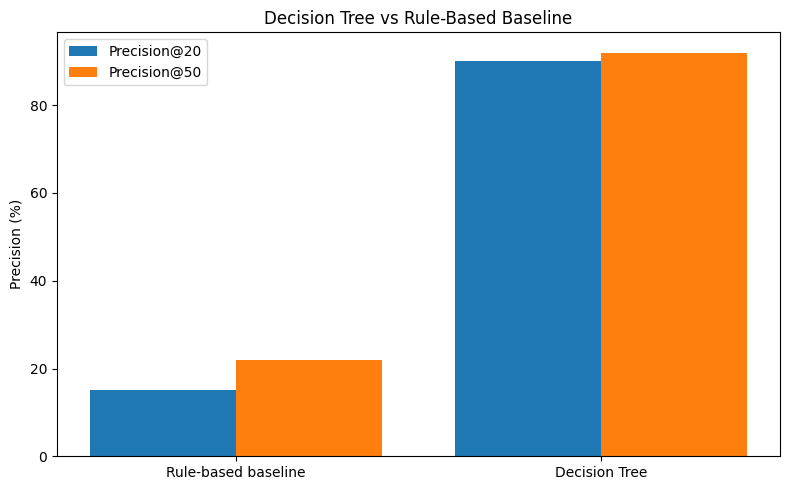

In [126]:
import matplotlib.pyplot as plt

plot_data = results.copy()

x = range(len(plot_data))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["Precision@20"] * 100,
    width=0.4,
    label="Precision@20"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["Precision@50"] * 100,
    width=0.4,
    label="Precision@50"
)

plt.xticks(
    list(x),
    plot_data["Method"]
)

plt.ylabel("Precision (%)")
plt.title("Decision Tree vs Rule-Based Baseline")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

Within the fitted Decision Tree, May impressions had the highest impurity-based feature importance, followed by May average position, May sessions, and May organic sessions.

These values describe how the fitted model used the available features. They should not be interpreted as causal effects or proof that these signals determine Google rankings.

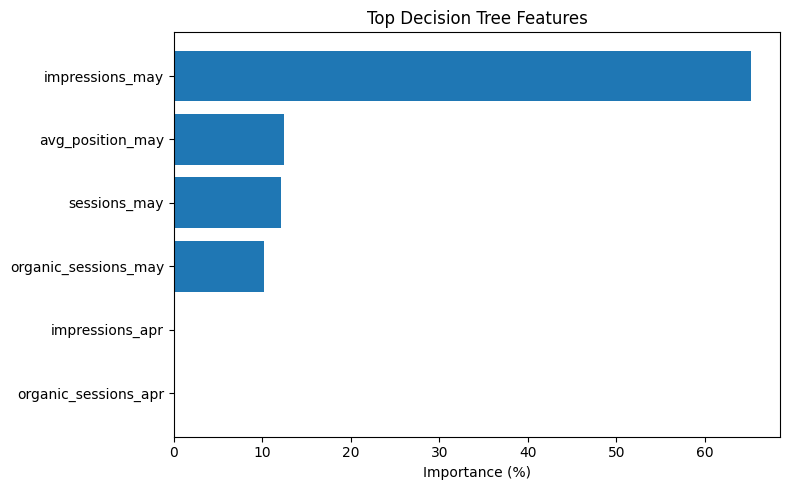

In [127]:
top_features = feature_importance.head(6).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"] * 100
)

plt.xlabel("Importance (%)")
plt.title("Top Decision Tree Features")
plt.tight_layout()
plt.show()

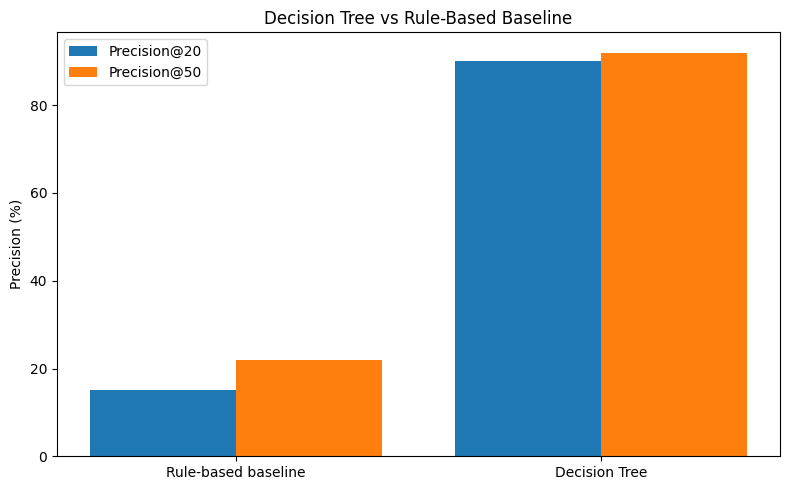

In [128]:
plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["Precision@20"] * 100,
    width=0.4,
    label="Precision@20"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["Precision@50"] * 100,
    width=0.4,
    label="Precision@50"
)

plt.xticks(
    list(x),
    plot_data["Method"]
)

plt.ylabel("Precision (%)")
plt.title("Decision Tree vs Rule-Based Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "results_model_vs_baseline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

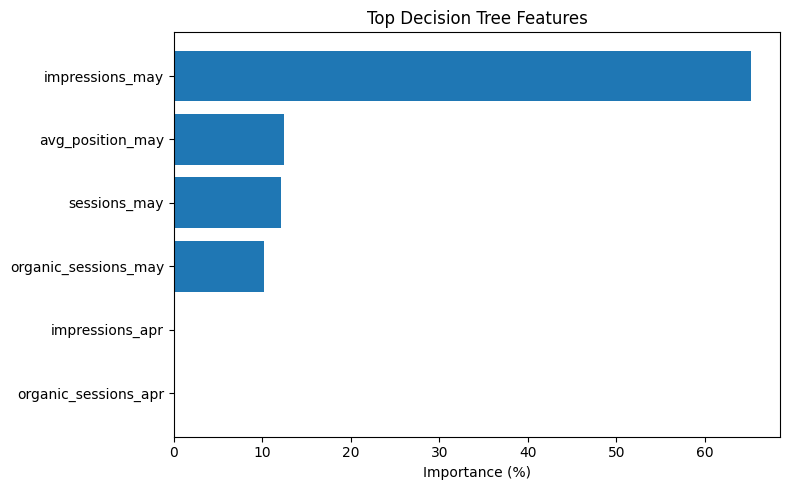

In [129]:
plt.figure(figsize=(8, 5))

top_features = feature_importance.head(6).sort_values(
    "importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"] * 100
)

plt.xlabel("Importance (%)")
plt.title("Top Decision Tree Features")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## 5. Limitations

This analysis has several limitations.

First, the evaluation uses a three-month window from April through June 2026, so the results should be treated as directional rather than broadly generalizable.

Second, the decline label is based on month-to-month changes in impressions. A decline in impressions does not prove that a page needs a content refresh or that refreshing the page would improve future performance.

Third, the Decision Tree is evaluated against a simple rule-based baseline on the same held-out test set. The measured improvement shows better prioritization performance on this dataset and split, but it does not prove causality or explain Google's ranking algorithm.

Fourth, some GA4-related fields were unavailable for a portion of the records and were treated as zero for modeling. This is an analytical assumption that may affect model behavior.

Finally, client identifiers, URLs, domains, private queries, and other identifying information are excluded from the public analysis. Therefore, the recommendations are intended as a general decision-support framework rather than client-specific SEO advice.

In [130]:
print("Evaluation period:")
print("April 2026 → June 2026")

print("\nPages evaluated:", len(model_data))

print(
    "Declining pages:",
    int(target.sum())
)

print(
    "Non-declining pages:",
    int((target == 0).sum())
)

Evaluation period:
April 2026 → June 2026

Pages evaluated: 156662
Declining pages: 121006
Non-declining pages: 35656


In [131]:
missing_values = features.isna().sum()

print("Total missing feature values:", missing_values.sum())

print("\nMissing values by feature:")
print(missing_values)

Total missing feature values: 0

Missing values by feature:
impressions_apr         0
impressions_may         0
clicks_apr              0
clicks_may              0
avg_position_apr        0
avg_position_may        0
sessions_apr            0
sessions_may            0
engaged_sessions_apr    0
engaged_sessions_may    0
organic_sessions_apr    0
organic_sessions_may    0
dtype: int64


## 6. Ranked Recommendations

The Decision Tree can be used to create a ranked review queue for pages showing signals associated with declining impressions.

The recommendations are intended for decision support. A high model score means that a page should be reviewed earlier; it does not mean that the page must be refreshed.

### Priority 1 — Review / Refresh Candidate

Pages with the highest predicted probability of decline should be reviewed first.

Recommended checks:

- Review recent impression and click trends.
- Check changes in average search position.
- Review organic session performance.
- Check whether the content may need updating or improvement.

### Priority 2 — Investigate

Pages with high predicted decline probability should be investigated after the highest-priority pages.

The analyst should review the available performance signals and determine whether a content review is appropriate.

### Priority 3 — Monitor

Pages with moderate predicted decline probability should be monitored over time.

No immediate content action is recommended based on the model score alone.

### Priority 4 — Protect / Monitor

Pages with low predicted decline probability do not require immediate refresh prioritization based on this model.

Their performance can continue to be monitored.

### Recommended Action Workflow

**Model ranking → Human review → Content decision → Future monitoring**

The model should therefore be treated as a prioritization system rather than an automatic content-refresh decision engine.

In [132]:
recommendations = model_data.loc[
    X_test.index,
    ["content_hash_id"]
].copy()

recommendations["decline_probability"] = tree_probability

recommendations["priority"] = pd.cut(
    recommendations["decline_probability"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=[
        "Priority 4 - Protect / Monitor",
        "Priority 3 - Monitor",
        "Priority 2 - Investigate",
        "Priority 1 - Review / Refresh Candidate"
    ]
)

recommendations = recommendations.sort_values(
    "decline_probability",
    ascending=False
)

recommendations.head(20)

,content_hash_id,decline_probability,priority
155904,content_93572e7f7493049a,0.732132,Priority 2 - Investigate
142883,content_870d327157a30ebf,0.732132,Priority 2 - Investigate
184351,content_ae17766e04de1118,0.732132,Priority 2 - Investigate
79122,content_4ac07645afd29def,0.732132,Priority 2 - Investigate
240437,content_e32db62831125998,0.732132,Priority 2 - Investigate
193941,content_b732aa5fa2eff0c9,0.732132,Priority 2 - Investigate
104340,content_6293df764f39793c,0.732132,Priority 2 - Investigate
208528,content_c515c594fc04f3d3,0.732132,Priority 2 - Investigate
98730,content_5d61a78f7ef3ce9f,0.732132,Priority 2 - Investigate
68867,content_411db15dd1de7dfe,0.732132,Priority 2 - Investigate


In [133]:
recommendation_summary = (
    recommendations["priority"]
    .value_counts()
    .rename_axis("priority")
    .reset_index(name="page_count")
)

recommendation_summary

,priority,page_count
0,Priority 2 - Investigate,25229
1,Priority 3 - Monitor,5434
2,Priority 4 - Protect / Monitor,670
3,Priority 1 - Review / Refresh Candidate,0


In [134]:
priority_order = [
    "Priority 1 - Review / Refresh Candidate",
    "Priority 2 - Investigate",
    "Priority 3 - Monitor",
    "Priority 4 - Protect / Monitor"
]

recommendation_summary["priority"] = pd.Categorical(
    recommendation_summary["priority"],
    categories=priority_order,
    ordered=True
)

recommendation_summary = recommendation_summary.sort_values(
    "priority"
)

recommendation_summary

,priority,page_count
3,Priority 1 - Review / Refresh Candidate,0
0,Priority 2 - Investigate,25229
1,Priority 3 - Monitor,5434
2,Priority 4 - Protect / Monitor,670


## 7. Artifacts the Paper Embeds

The analysis produces several artifacts for the deployed research paper.

These artifacts summarize the model performance, the main features used by the Decision Tree, and the ranked recommendation output.

The paper embeds:

1. Model vs baseline results table
2. Model vs baseline Precision chart
3. Decision Tree feature importance chart
4. Recommendation priority summary

All public artifacts use aggregated results and do not expose client names, URLs, domains, private queries, or raw warehouse records.

In [135]:
# Final model vs baseline results

results_display

,Method,Precision@20,Precision@50
0,Rule-based baseline,15.0,22.0
1,Decision Tree,90.0,92.0


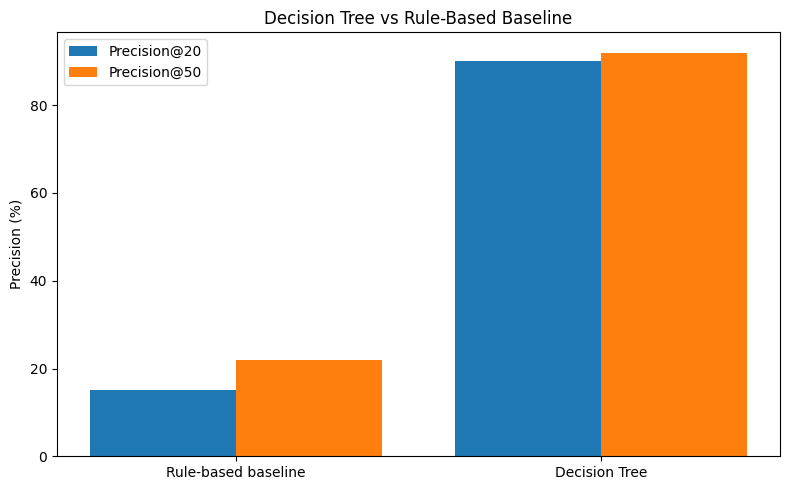

In [136]:
import matplotlib.pyplot as plt

plot_data = results.copy()

x = range(len(plot_data))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["Precision@20"] * 100,
    width=0.4,
    label="Precision@20"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["Precision@50"] * 100,
    width=0.4,
    label="Precision@50"
)

plt.xticks(
    list(x),
    plot_data["Method"]
)

plt.ylabel("Precision (%)")
plt.title("Decision Tree vs Rule-Based Baseline")
plt.legend()
plt.tight_layout()

plt.show()

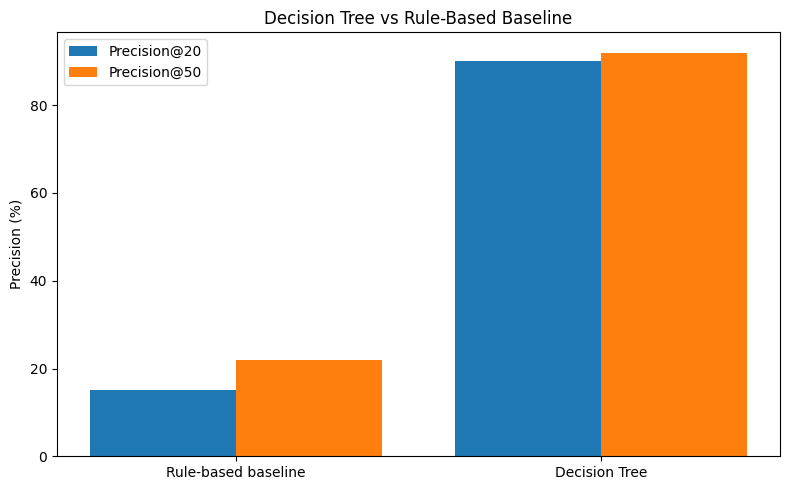

In [137]:
plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["Precision@20"] * 100,
    width=0.4,
    label="Precision@20"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["Precision@50"] * 100,
    width=0.4,
    label="Precision@50"
)

plt.xticks(
    list(x),
    plot_data["Method"]
)

plt.ylabel("Precision (%)")
plt.title("Decision Tree vs Rule-Based Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "results_model_vs_baseline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [138]:
# Feature importance table

feature_importance

,feature,importance
1,impressions_may,6.522311e-01
5,avg_position_may,1.243085e-01
7,sessions_may,1.211484e-01
11,organic_sessions_may,1.013751e-01
0,impressions_apr,9.367883e-04
10,organic_sessions_apr,2.029516e-14
3,clicks_may,0.000000e+00
2,clicks_apr,0.000000e+00
6,sessions_apr,0.000000e+00
4,avg_position_apr,0.000000e+00


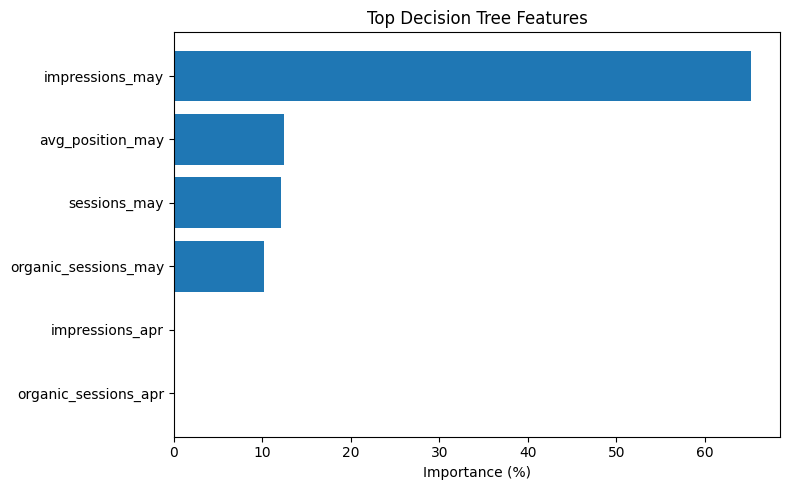

In [139]:
top_features = feature_importance.head(6).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"] * 100
)

plt.xlabel("Importance (%)")
plt.title("Top Decision Tree Features")
plt.tight_layout()

plt.show()

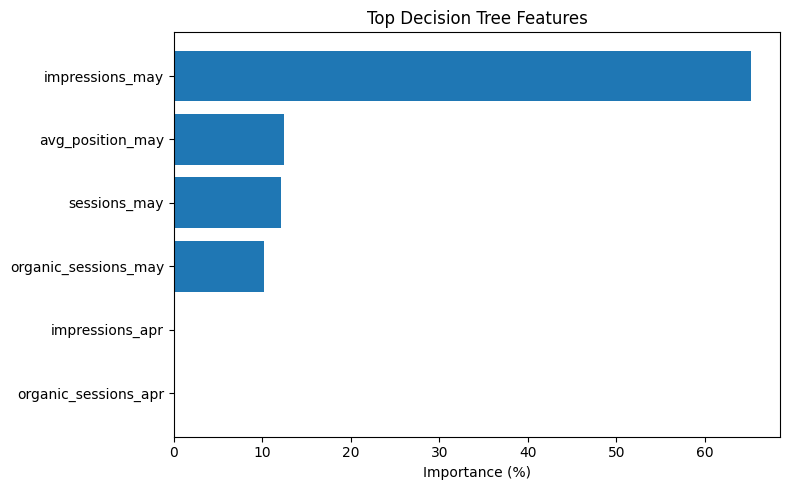

In [140]:
plt.figure(figsize=(8, 5))

top_features = feature_importance.head(6).sort_values(
    "importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"] * 100
)

plt.xlabel("Importance (%)")
plt.title("Top Decision Tree Features")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [141]:
recommendation_summary

,priority,page_count
3,Priority 1 - Review / Refresh Candidate,0
0,Priority 2 - Investigate,25229
1,Priority 3 - Monitor,5434
2,Priority 4 - Protect / Monitor,670


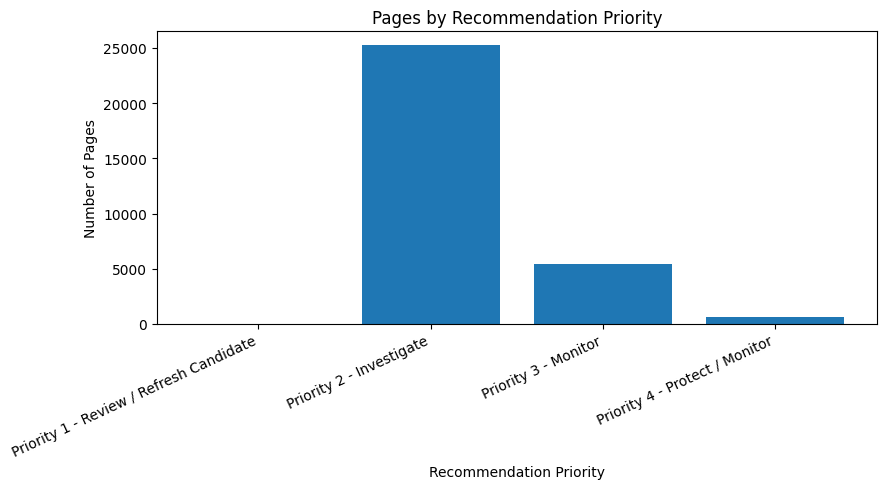

In [142]:
plt.figure(figsize=(9, 5))

plt.bar(
    recommendation_summary["priority"].astype(str),
    recommendation_summary["page_count"]
)

plt.ylabel("Number of Pages")
plt.xlabel("Recommendation Priority")
plt.title("Pages by Recommendation Priority")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()

# 5-Minute Demo Outline

### 1. Problem — 45 seconds
Explain that the project asks whether a simple Decision Tree can improve prioritization of pages showing declining search visibility compared with a rule-based baseline.

### 2. Data — 45 seconds
Explain that the analysis uses FlyRank internship warehouse data from April through June 2026, using page-level search and engagement signals.

### 3. Method — 1 minute
Explain the declining-impression label, the selected features, the rule-based baseline, the Decision Tree, and the train/test evaluation.

### 4. Results — 1 minute
Show the Precision@20 and Precision@50 comparison.

The rule-based baseline achieved 15% Precision@20 and 22% Precision@50, while the Decision Tree achieved 90% and 92%, respectively.

### 5. Recommendations and limitations — 45 seconds
Explain that the model creates a ranked review queue and should be used for decision support rather than automatic content-refresh decisions.

### Closing — 45 seconds
Summarize that the model showed stronger measured prioritization performance on this evaluation setup, while avoiding causal claims about Google's ranking system or future content-refresh impact.

# Social Post

I built a machine learning capstone using real FlyRank search-performance data to study whether a simple Decision Tree could improve content-refresh prioritization.

The model was compared with a rule-based baseline using Precision@20 and Precision@50.

On the evaluation split, the Decision Tree achieved 90% Precision@20 and 92% Precision@50, compared with 15% and 22% for the baseline.

The result is a decision-support workflow for creating a ranked page-review queue — not a claim about Google's ranking algorithm or the causal impact of content refreshes.

Built as part of the FlyRank ML Internship.

# Employer-Facing Summary

I built a Decision Tree-based prioritization system using real search-performance data to identify pages showing declining visibility signals. The model was evaluated against a rule-based baseline using Precision@20 and Precision@50, achieving 90% and 92% precision on the evaluation split. The project demonstrates practical skills in data preparation, feature engineering, leakage-aware modeling, model evaluation, ranking, visualization, and translating machine-learning results into actionable decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
